In [23]:
from qubic.lib.Qhdf5 import HDF5Dict
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

from qubic.lib.QskySim import get_angular_profile

plt.rcParams["figure.dpi"] = 100

## Load all `test_conv` runs

In [24]:
hdf5 = HDF5Dict()

folders = sorted(
    glob.glob("parametric_d0_DB_test_conv_*_100"),
    key=lambda f: int(re.search(r"test_conv_(\d+)_100", f).group(1)),
)

data = {}
for folder in folders:
    niter = int(re.search(r"test_conv_(\d+)_100", folder).group(1))
    path = glob.glob(f"{folder}/Dict/test_*.h5")[0]
    data[niter] = hdf5.load_dict(path)

n_iter_values = sorted(data.keys())
print("n_iter_pcg values found:", n_iter_values)

colors = plt.cm.viridis(np.linspace(0, 1, len(n_iter_values)))
color_of = dict(zip(n_iter_values, colors))

n_iter_pcg values found: [5, 10, 12, 15, 17, 20, 25, 30]


In [25]:
# Sanity check: only n_iter_pcg changes between runs
ref = data[n_iter_values[0]]
beta_true = ref["beta_true"][0]
comps_name = [c.decode() if isinstance(c, bytes) else c for c in ref["comps_name"]]
seenpix = ref["seenpix"]
center = ref["center"]

for niter in n_iter_values:
    p = data[niter]["parameters"]["PCG"]
    print(
        f"n_iter_pcg={niter:>3d}  n_init_iter_pcg={p['n_init_iter_pcg']}  "
        f"n_iter_loop={p['n_iter_loop']}  iter_end={p['iter_end']}  "
        f"len(beta)={len(data[niter]['beta'])}"
    )

print()
print("beta_true =", beta_true)
print("components:", comps_name)
print("fsky:", ref["fsky"])

n_iter_pcg=  5  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 10  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 12  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 15  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 17  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 20  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 25  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101
n_iter_pcg= 30  n_init_iter_pcg=15  n_iter_loop=100  iter_end=150  len(beta)=101

beta_true = 1.54
components: ['CMB', 'Dust']
fsky: 0.025969187418619793


## PCG convergence within a single outer-loop step

For a given outer-loop step, `convergence[k]` is the residual of the PCG solver at each of its
internal iterations. Comparing these curves across `n_iter_pcg` values shows how much residual
is left on the table when the PCG is cut short.

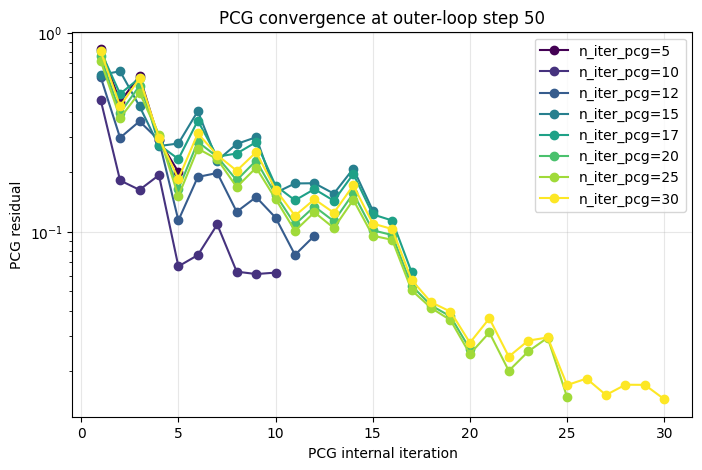

In [26]:
outer_step = 50  # pick a representative outer-loop step, away from the first (longer) one

plt.figure(figsize=(8, 5))
for niter in n_iter_values:
    conv = data[niter]["convergence"][outer_step]
    plt.plot(np.arange(1, len(conv) + 1), conv, "o-", color=color_of[niter], label=f"n_iter_pcg={niter}")

plt.xlabel("PCG internal iteration")
plt.ylabel("PCG residual")
plt.yscale("log")
plt.title(f"PCG convergence at outer-loop step {outer_step}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Convergence of beta with the outer loop iterations

`beta` is a single global spectral index (dust), saved at every outer-loop step. We look at both
its raw value and its distance to `beta_true`.

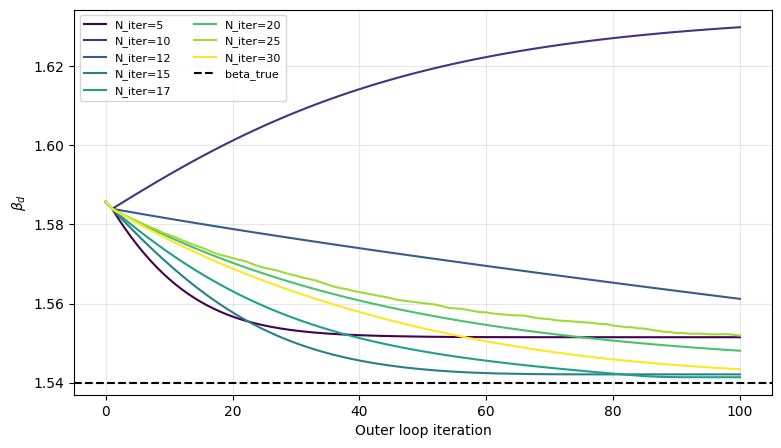

In [27]:
plt.figure(figsize=(9, 5))
for niter in n_iter_values:
    beta = np.array(data[niter]["beta"]).flatten()
    plt.plot(beta, color=color_of[niter], label=f"N_iter={niter}")

plt.axhline(beta_true, color="black", linestyle="--", label="beta_true")
plt.xlabel("Outer loop iteration")
plt.ylabel(r"$\beta_d$")
# plt.title("Beta convergence vs outer loop iteration")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

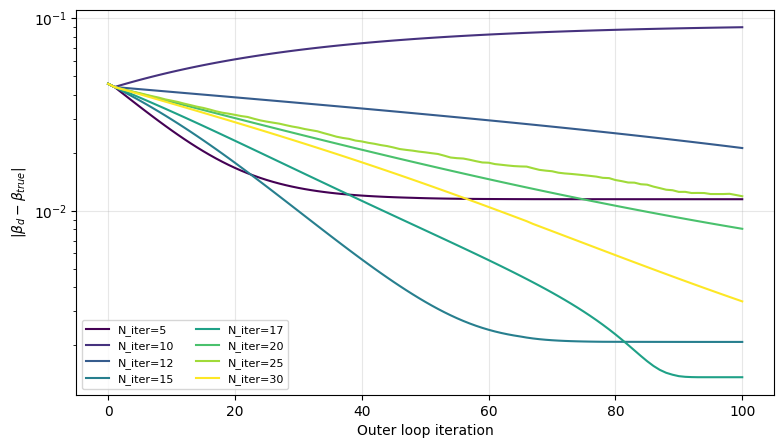

In [28]:
plt.figure(figsize=(9, 5))
for niter in n_iter_values:
    beta = np.array(data[niter]["beta"]).flatten()
    plt.plot(np.abs(beta - beta_true), color=color_of[niter], label=f"N_iter={niter}")

plt.xlabel("Outer loop iteration")
plt.ylabel(r"$|\beta_d - \beta_{true}|$")
plt.yscale("log")
# plt.title("Beta absolute error vs outer loop iteration")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

### Iterations needed for beta to stop changing, and final accuracy

Convergence is defined directly on `beta`, not on its distance to `beta_true` (which we would not
know in a real analysis): for each `n_iter_pcg`, we find the first outer-loop iteration after
which the relative step-to-step change in `beta` (`|beta[i+1] - beta[i]| / |beta[i]|`) permanently
stays below a small, fixed tolerance. Runs that truly settle show this ratio drop to floating-point
noise (~1e-8), while runs that only *slow down* but keep drifting linearly plateau around ~1e-4 and
never cross the tolerance — so they correctly come back as "not converged" rather than being
mistaken for convergence.

In [29]:
tol_rel = 1e-5  # relative tolerance on the beta step-to-step change, |beta[i+1] - beta[i]| / |beta[i]|

print(f"{'n_iter_pcg':>10s}  {'iter to converge':>17s}  {'final beta':>11s}  {'final rel. error':>17s}")
print("-" * 62)

n_iter_to_converge = {}
final_error = {}
for niter in n_iter_values:
    beta = np.array(data[niter]["beta"]).flatten()
    rel_diffs = np.abs(np.diff(beta)) / np.abs(beta[1:])

    stable_mask = rel_diffs < tol_rel
    # first iteration after which beta *stops changing* (relative step stays below tol_rel)
    ite_conv = next(
        (i for i in range(len(stable_mask)) if np.all(stable_mask[i:])),
        None,
    )
    n_iter_to_converge[niter] = ite_conv
    final_error[niter] = np.abs(beta[-1] - beta_true) / np.abs(beta_true)

    print(f"{niter:>10d}  {str(ite_conv):>17s}  {beta[-1]:>11.5f}  {final_error[niter]:>17.2e}")

n_iter_pcg   iter to converge   final beta   final rel. error
--------------------------------------------------------------
         5                 52      1.55148           7.46e-03
        10               None      1.62987           5.84e-02
        12               None      1.56118           1.38e-02
        15                 68      1.54208           1.35e-03
        17                 90      1.54137           8.86e-04
        20               None      1.54806           5.23e-03
        25               None      1.55190           7.72e-03
        30               None      1.54338           2.20e-03


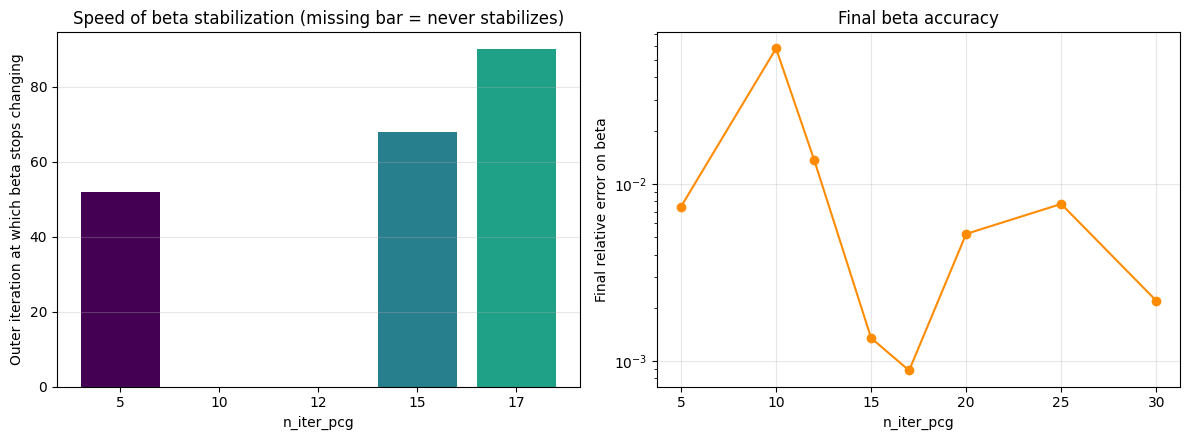

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# n_iter_to_converge can be None if beta's step-to-step change never permanently settles below tol_diff
conv_heights = [n_iter_to_converge[n] if n_iter_to_converge[n] is not None else np.nan for n in n_iter_values]
axes[0].bar([str(n) for n in n_iter_values], conv_heights, color=colors)
axes[0].set_xlabel("n_iter_pcg")
axes[0].set_ylabel("Outer iteration at which beta stops changing")
axes[0].set_title("Speed of beta stabilization (missing bar = never stabilizes)")
axes[0].grid(alpha=0.3, axis="y")

axes[1].plot(n_iter_values, [final_error[n] for n in n_iter_values], "o-", color="darkorange")
axes[1].set_xlabel("n_iter_pcg")
axes[1].set_ylabel("Final relative error on beta")
axes[1].set_yscale("log")
axes[1].set_title("Final beta accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Noise profile of the reconstructed maps

`maps_noise` is the pure-noise reconstructed map (map obtained from noise-only TOD, propagated
through the same map-making). Its angular profile (RMS vs distance to the patch center) shows
whether cutting PCG short leaves extra noise / non-stationarity in the maps.

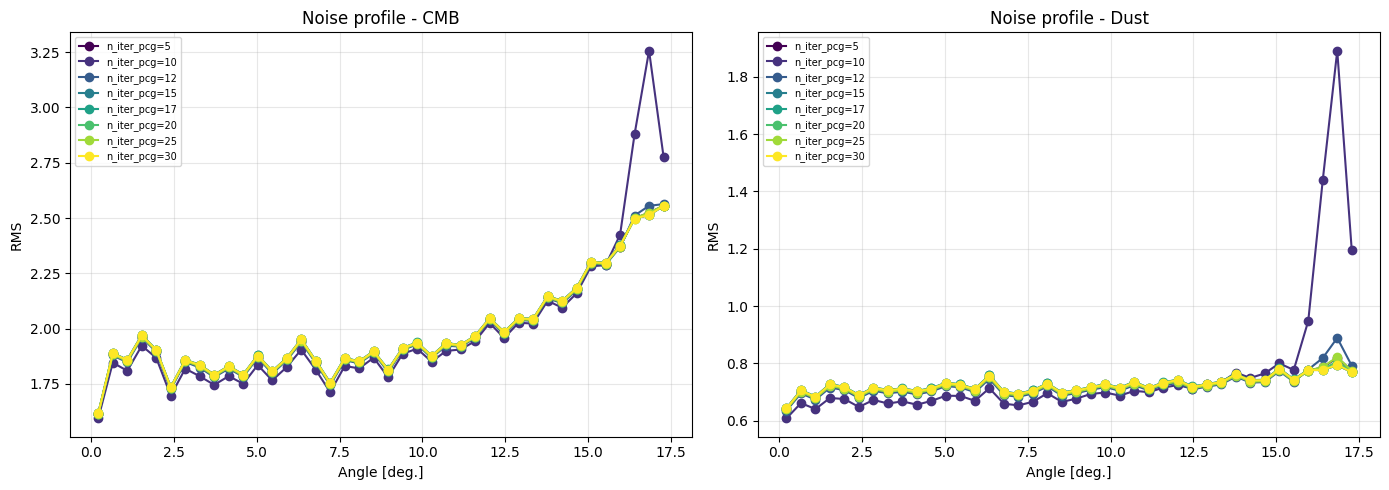

In [31]:
fig, axes = plt.subplots(1, len(comps_name), figsize=(7 * len(comps_name), 5))

for icomp, comp in enumerate(comps_name):
    plt.sca(axes[icomp])
    for niter in n_iter_values:
        xx, avg = get_angular_profile(
            data[niter]["maps_noise"][icomp],
            doplot=False,
            nbins=40,
            thmax=17.5,
        )
        axes[icomp].plot(xx, avg, "o-", color=color_of[niter], label=f"n_iter_pcg={niter}")
    axes[icomp].set_xlabel("Angle [deg.]")
    axes[icomp].set_ylabel("RMS")
    axes[icomp].set_title(f"Noise profile - {comp}")
    axes[icomp].legend(fontsize=7)
    axes[icomp].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Noise level in the QUBIC patch vs `n_iter_pcg`

Average noise RMS over the seen pixels, for each component and Stokes parameter.

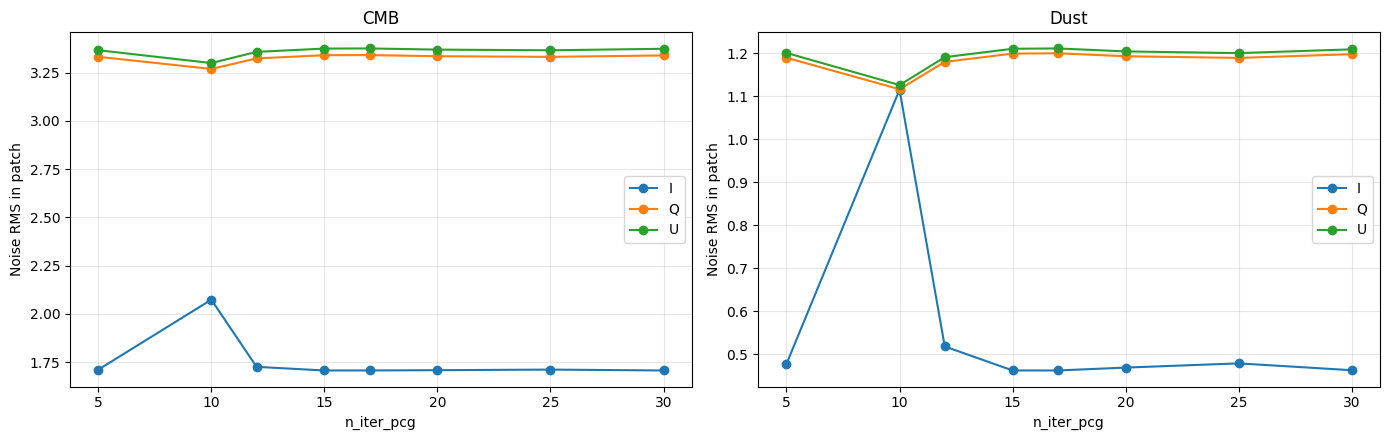

In [32]:
STOKES = ["I", "Q", "U"]

fig, axes = plt.subplots(1, len(comps_name), figsize=(7 * len(comps_name), 4.5), squeeze=False)
axes = axes[0]

for icomp, comp in enumerate(comps_name):
    for istk, stk in enumerate(STOKES):
        sigma = [np.std(data[niter]["maps_noise"][icomp, seenpix, istk]) for niter in n_iter_values]
        axes[icomp].plot(n_iter_values, sigma, "o-", label=stk)
    axes[icomp].set_xlabel("n_iter_pcg")
    axes[icomp].set_ylabel("Noise RMS in patch")
    axes[icomp].set_title(comp)
    axes[icomp].legend()
    axes[icomp].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Reconstruction residuals vs `n_iter_pcg`

Standard deviation of `maps - maps_in` over the seen pixels, for each component and Stokes
parameter, as a function of `n_iter_pcg`. Since `convolution_in`/`convolution_out` are `False`
here, `maps_in` can be compared directly to `maps` without extra smoothing.

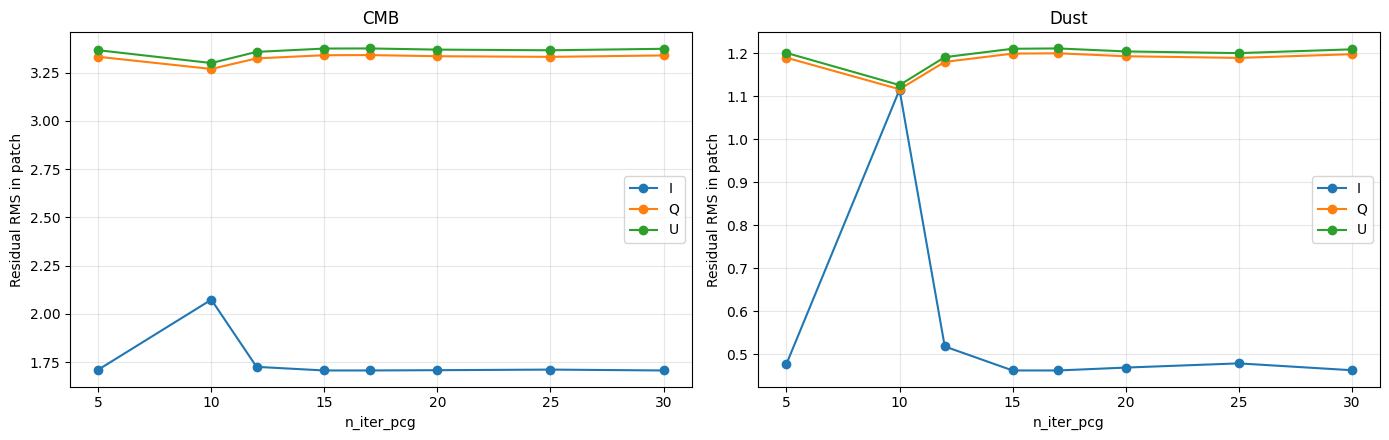

In [33]:
fig, axes = plt.subplots(1, len(comps_name), figsize=(7 * len(comps_name), 4.5), squeeze=False)
axes = axes[0]

for icomp, comp in enumerate(comps_name):
    for istk, stk in enumerate(STOKES):
        sigma_res = [
            np.std(data[niter]["maps"][icomp, seenpix, istk] - data[niter]["maps_in"][icomp, seenpix, istk])
            for niter in n_iter_values
        ]
        axes[icomp].plot(n_iter_values, sigma_res, "o-", label=stk)
    axes[icomp].set_xlabel("n_iter_pcg")
    axes[icomp].set_ylabel("Residual RMS in patch")
    axes[icomp].set_title(comp)
    axes[icomp].legend()
    axes[icomp].grid(alpha=0.3)

plt.tight_layout()
plt.show()